# Introduction
The current project is Linear Regression project on Latest Indian stock market data provided by NSE using yahoofinance module, the project aimms to understand how linear regression and it's evaluation metrics work

> **Disclaimer:** For learning purposes only — not a trading signal or financial advice. This notebook demonstrates regression methodology on stock data, not prediction accuracy.

In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,PolynomialFeatures
from sklearn.metrics import (r2_score,mean_squared_error,
                             mean_absolute_error)
from sklearn.linear_model import (LinearRegression,Ridge,Lasso)

In [2]:
df = yf.download("^NSEI", period="3y",auto_adjust=True)
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI
Date,,,,,
2023-07-06,19497.300781,19512.199219,19373.000000,19385.699219,268300
2023-07-07,19331.800781,19523.599609,19303.599609,19422.800781,237100
2023-07-10,19355.900391,19435.849609,19327.099609,19400.349609,268200
2023-07-11,19439.400391,19515.099609,19406.449219,19427.099609,251300
2023-07-12,19384.300781,19507.699219,19361.750000,19497.449219,327900


## EDA

In [3]:
df.columns = df.columns.droplevel(1)
display(df.columns)
display(f"Shape of dataFrame: {df.shape}")
df.info()

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')

'Shape of dataFrame: (738, 5)'

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 738 entries, 2023-07-06 to 2026-07-06
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   738 non-null    float64
 1   High    738 non-null    float64
 2   Low     738 non-null    float64
 3   Open    738 non-null    float64
 4   Volume  738 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 34.6 KB


In [4]:
df.describe()

Price,Close,High,Low,Open,Volume
count,738.000000,738.000000,738.000000,738.000000,7.380000e+02
mean,23412.834514,23521.620930,23301.501503,23419.762460,3.241000e+05
std,1968.852837,1978.601307,1962.930641,1970.419769,1.164990e+05
min,18857.250000,19041.699219,18837.849609,18928.750000,0.000000e+00
25%,22231.512207,22380.462891,22082.350098,22250.537109,2.512250e+05
50%,23913.924805,24069.925781,23816.975586,23925.525391,3.011500e+05
75%,24933.475098,25034.149414,24811.861816,24944.950195,3.764500e+05
max,26328.550781,26373.199219,26210.050781,26333.699219,1.198000e+06


In [5]:
df.isna().sum()

,0
Price,
Close,0
High,0
Low,0
Open,0
Volume,0


## Data & Feature Engineering

The given datasett does not have a target variable and even the input featured are not very suffiecient alone and hence we need to create features that would be helful


In [6]:
df['Target'] = df['Close'].pct_change().shift(-1)
df

Price,Close,High,Low,Open,Volume,Target
Date,,,,,,
2023-07-06,19497.300781,19512.199219,19373.000000,19385.699219,268300,-0.008488
2023-07-07,19331.800781,19523.599609,19303.599609,19422.800781,237100,0.001247
2023-07-10,19355.900391,19435.849609,19327.099609,19400.349609,268200,0.004314
2023-07-11,19439.400391,19515.099609,19406.449219,19427.099609,251300,-0.002834
2023-07-12,19384.300781,19507.699219,19361.750000,19497.449219,327900,0.001519
...,...,...,...,...,...,...
2026-06-30,23865.750000,24035.550781,23829.199219,24032.050781,449000,0.005870
2026-07-01,24005.849609,24049.900391,23895.099609,23897.650391,352100,0.007075
2026-07-02,24175.699219,24194.550781,24058.800781,24062.199219,372900,0.003936


We shift by -1 because we’re predicting tomorrow’s return using today’s features. If we didn’t shift, we’d be leaking future data.

In [7]:
df['MA5'] = df['Close'].rolling(5).mean()
df['MA20'] = df['Close'].rolling(20).mean()
df['MA_ratio'] = df['MA5'] / df['MA20'] # above 1 means short-term uptrend
df['Return'] = df['Close'].pct_change()
df['Volatility'] = df['Return'].rolling(10).std()
df['Vol_change'] = df['Volume'].pct_change()

In [8]:
df = df.replace([np.inf,-np.inf],np.nan)
df = df.dropna()
print(df.shape)
df.isna().sum()

(712, 12)


,0
Price,
Close,0
High,0
Low,0
Open,0
Volume,0
Target,0
MA5,0
MA20,0
MA_ratio,0


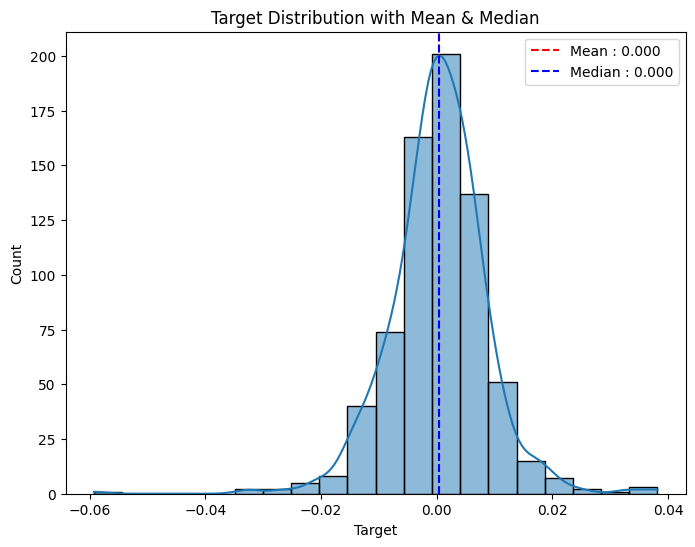

In [9]:
fig,ax= plt.subplots(figsize=(8,6))
sns.histplot(data=df['Target'],bins=20,kde=True)
ax.axvline(np.mean(df['Target']),color='red',linestyle='--',label=f'Mean : {np.mean(df['Target']):.3f}')
ax.axvline(np.median(df['Target']),color='blue',linestyle='--',label=f'Median : {np.median(df['Target']):.3f}')
ax.set_title('Target Distribution with Mean & Median')
ax.legend()
plt.show()

The distribution is roughly symmetric, since the mean and median are both close to 0.000. It appears Leptokurtic — the frequency is very high near the mean and drops off sharply moving away from it, suggesting fatter tails and a sharper peak than a Normal distribution.

## Model Training

**Train-test split strategy:** We are using time based splliting i.e., using latest data for testing and older for training, ass randomly selected data for testing in a time series model may be interpolated by the training point closer to them.

X-training length: 569 	 X-testing length: 143
y-training length: 569 	 Y-testing length: 143


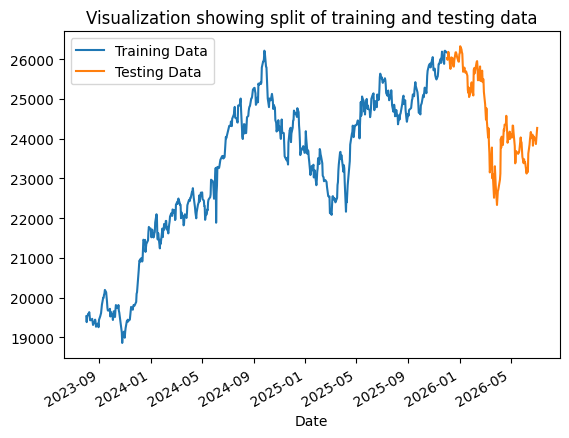

In [10]:
y = df['Target']
X = df.drop(columns=['Target'])
threshold = int(np.floor(len(X)*0.8))

X_train = X.iloc[:threshold]
X_test = X.iloc[threshold:]

y_train = y.iloc[:threshold]
y_test = y.iloc[threshold:]

print(f"X-training length: {len(X_train)} \t X-testing length: {len(X_test)}")
print(f"y-training length: {len(y_train)} \t Y-testing length: {len(y_test)}")

X_train["Close"].plot(kind='line',label="Training Data")
X_test["Close"].plot(kind='line',label="Testing Data")
plt.title("Visualization showing split of training and testing data")
plt.legend()
plt.show()

## Feature Scaling

In [11]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Model Testing , Evaluation & Model Comparison

In [12]:
lr = LinearRegression(fit_intercept=True).fit(X_train,y_train)
y_pred_lr = lr.predict(X_test)

rr = Ridge(alpha=1.0).fit(X_train,y_train)
y_pred_ridge = rr.predict(X_test)

lasso = Lasso(alpha=0.001).fit(X_train,y_train)
y_pred_lasso =lasso.predict(X_test)

results_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression', 'Lasso Regression'],
    'MAE': [mean_absolute_error(y_test, p) for p in [y_pred_lr, y_pred_ridge, y_pred_lasso]],
    'RMSE': [mean_squared_error(y_test, p)**0.5 for p in [y_pred_lr, y_pred_ridge, y_pred_lasso]],
    'R2': [r2_score(y_test, p) for p in [y_pred_lr, y_pred_ridge, y_pred_lasso]]
}).round(4)
results_df

,Model,MAE,RMSE,R2
0,Linear Regression,0.0073,0.0099,-0.0317
1,Ridge Regression,0.0073,0.0100,-0.0426
2,Lasso Regression,0.0074,0.0098,-0.0091


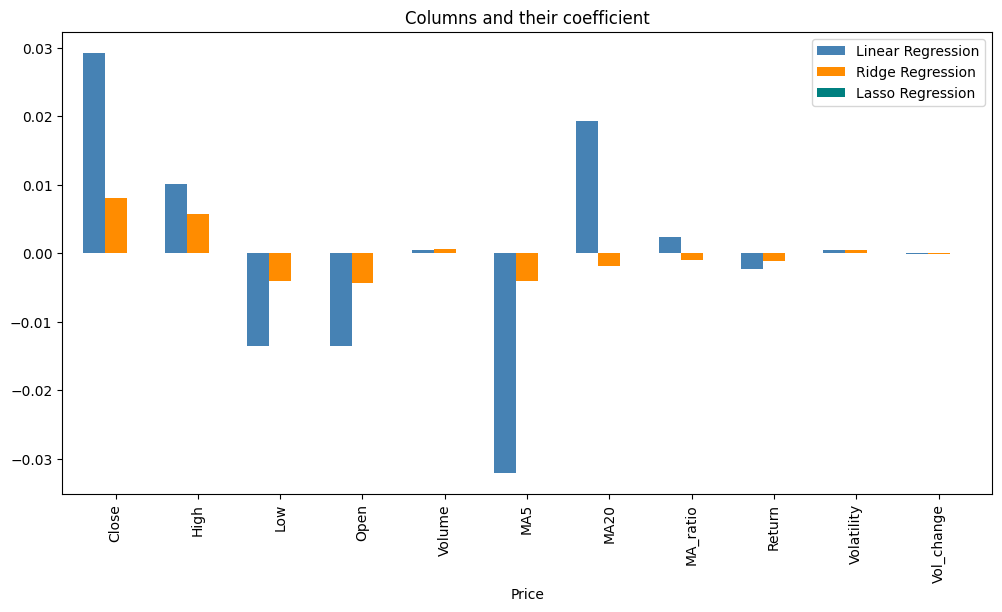

In [13]:
coef_df = pd.DataFrame({
    'Linear Regression': lr.coef_,
    'Ridge Regression': rr.coef_,
    'Lasso Regression': lasso.coef_
}, index=X.columns)

fig, ax = plt.subplots(figsize=(12, 6))
coef_df.plot(kind='bar', ax=ax, color=['steelblue', 'darkorange', 'teal'], width=0.8)
plt.title("Columns and their coefficient")
plt.legend()

plt.show()

In [14]:
lasso_coeff = pd.Series(lasso.coef_, index=X.columns)
lasso_coeff

,0
Price,
Close,-0.0
High,-0.0
Low,-0.0
Open,-0.0
Volume,0.0
MA5,-0.0
MA20,-0.0
MA_ratio,-0.0
Return,-0.0


Lasso eliminated all features because their coefficients are exactly zero. This means they contributed little predictive signal given the other features.

# Honest Interpretation

R² on stock return prediction is likely very low (possibly negative). This is expected — returns are noisy and near-random over short horizons. The value of this project is not prediction accuracy but demonstrating correct methodology: feature engineering, time-series splitting, regularization, and metric reporting.